In [89]:
import pandas as pd
from pathlib import Path
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [2]:
processed_path = Path("../data/processed")
amazon_pairs = pd.read_parquet(
    processed_path / "amazon_support_pairs.parquet"
)

print(amazon_pairs.shape)
print(amazon_pairs.columns.tolist())

(166963, 18)
['support_tweet_id', 'support_author', 'inbound_support', 'support_created_at', 'support_text', 'response_tweet_id', 'in_response_to_tweet_id', 'text_length', 'customer_tweet_id', 'tweet_id_customer', 'customer_author', 'customer_inbound', 'customer_text', 'customer_created_at', 'customer_text_clean', 'clean_length', 'mention_only', 'low_information']


In [3]:
intent_sample = amazon_pairs.sample(
    n=5000,
    random_state=42
).copy()

print(intent_sample.shape)

(5000, 18)


In [4]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90
)

In [5]:
X = vectorizer.fit_transform(
    intent_sample["customer_text_clean"]
)

print("TF-IDF shape:", X.shape)

TF-IDF shape: (5000, 2037)


In [6]:
terms = vectorizer.get_feature_names_out()

scores = X.mean(axis=0).A1

tfidf_terms = (
    pd.DataFrame({
        "term": terms,
        "score": scores
    })
    .sort_values(
        "score",
        ascending=False
    )
)

tfidf_terms.head(50)

,term,score
127,amazon,0.028443
1239,order,0.023280
503,delivery,0.019645
1409,prime,0.016575
1640,service,0.014213
964,just,0.012994
437,customer,0.012744
494,delivered,0.012551
858,help,0.011972
462,day,0.011042


In [7]:
tfidf_terms[
    tfidf_terms["term"].str.contains(" ")
].head(50)

,term,score
440,customer service,0.006587
463,day delivery,0.003661
144,amazon prime,0.003575
438,customer care,0.003109
465,day shipping,0.002658
508,delivery date,0.002081
291,cancel order,0.001901
1416,prime member,0.001867
1418,prime membership,0.001849
1014,let know,0.001623


In [8]:
keywords = [
    "delivery",
    "refund",
    "return",
    "payment",
    "account",
    "order",
    "prime",
    "tracking"
]

for keyword in keywords:

    print("\n" + "=" * 80)
    print("KEYWORD:", keyword.upper())

    matches = intent_sample[
        intent_sample["customer_text_clean"]
        .str.lower()
        .str.contains(keyword, na=False)
    ]

    for text in matches[
        "customer_text_clean"
    ].sample(
        min(10, len(matches)),
        random_state=42
    ):
        print("-", text)


KEYWORD: DELIVERY
- If is going to do its own package delivery, it might want to ask and for simple tips on stopping package theft...
- I needed the item yesterday, I bought a more expensive one as it had Prime delivery. Waste of money.
- It worked out I caught the delivery guy on my way out the door at 8, thanks
- I ordered 4 items 1 is being delivered by UPS. It can be tracked and us arriving on time as usual for the other three, which are over $200 are late. No exact delivery date is given! there is no useful tracking information! #frustrating
- Ffs , I ordered a fire 7 yesterday, for delivery today, didn’t ship till gone 3 today, won’t arrive till Tuesday! Why not sat, sun or mon?
- Been waiting for Prime delivery promised today from and according to tracking it’s not even out for delivery yet. Be less stressful getting a taxi into town to buy the item.
- You guys seem to have started a new business model altogether. Charge your customer 150rs. for 1 day delivery and yet dont deli

In [9]:
intent_sample = amazon_pairs.sample(
    n=5000,
    random_state=42
).copy()

intent_sample[[
    "customer_text",
    "customer_text_clean",
    "support_text"
]].head()

,customer_text,customer_text_clean,support_text
161938,@115830 how about it not take 30 mins phone ca...,how about it not take 30 mins phone call to tr...,"@805438 Hey Robert, thanks for reaching out to..."
38240,"@AmazonHelp Si, es de Amazon. Y con Amazon no ...","Si, es de Amazon. Y con Amazon no tengo inconv...","@137604 Gonzalo, por favor contacta con nuestr..."
20578,Leadership team @115850 believes only on hollo...,Leadership team believes only on hollow words ...,@186821 I'd like to help. Please write to us h...
161521,@AmazonHelp is there anyway to get a seller sh...,is there anyway to get a seller shut down? I'v...,@804137 We'll remove a seller if they violate ...
108461,@UPSHelp and @AmazonHelp you two need to tal...,and you two need to talk to each other there i...,@472074 I'm very sorry about delay in delivery...


In [10]:
candidate_terms = [
    "delivery",
    "refund",
    "return",
    "payment",
    "account",
    "prime",
    "tracking",
    "order"
]

for term in candidate_terms:

    matches = intent_sample[
        intent_sample["customer_text_clean"]
        .str.lower()
        .str.contains(term, na=False)
    ]

    print("\n" + "=" * 100)
    print(f"{term.upper()} ({len(matches)} matches)")

    for text in matches[
        "customer_text_clean"
    ].sample(
        min(8, len(matches)),
        random_state=42
    ):
        print("-", text)


DELIVERY (490 matches)
- If is going to do its own package delivery, it might want to ask and for simple tips on stopping package theft...
- I needed the item yesterday, I bought a more expensive one as it had Prime delivery. Waste of money.
- It worked out I caught the delivery guy on my way out the door at 8, thanks
- I ordered 4 items 1 is being delivered by UPS. It can be tracked and us arriving on time as usual for the other three, which are over $200 are late. No exact delivery date is given! there is no useful tracking information! #frustrating
- Ffs , I ordered a fire 7 yesterday, for delivery today, didn’t ship till gone 3 today, won’t arrive till Tuesday! Why not sat, sun or mon?
- Been waiting for Prime delivery promised today from and according to tracking it’s not even out for delivery yet. Be less stressful getting a taxi into town to buy the item.
- You guys seem to have started a new business model altogether. Charge your customer 150rs. for 1 day delivery and yet dont

### English Model(for tweets which serves meaning only in English Language)

In [45]:
model_en = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4055.55it/s]


In [ ]:
texts = intent_sample[
    "customer_text_clean"
].tolist()

embeddings = model_en.encode(
    texts,
    show_progress_bar=True,
    batch_size=64
)

print("Embedding shape:", embeddings.shape)

Batches: 100%|██████████| 79/79 [00:35<00:00,  2.23it/s]

Embedding shape: (5000, 384)


In [ ]:
pca = PCA(
    n_components=2,
    random_state=42
)

embeddings_2d = pca.fit_transform(
    embeddings
)

print(embeddings_2d.shape)

(5000, 2)


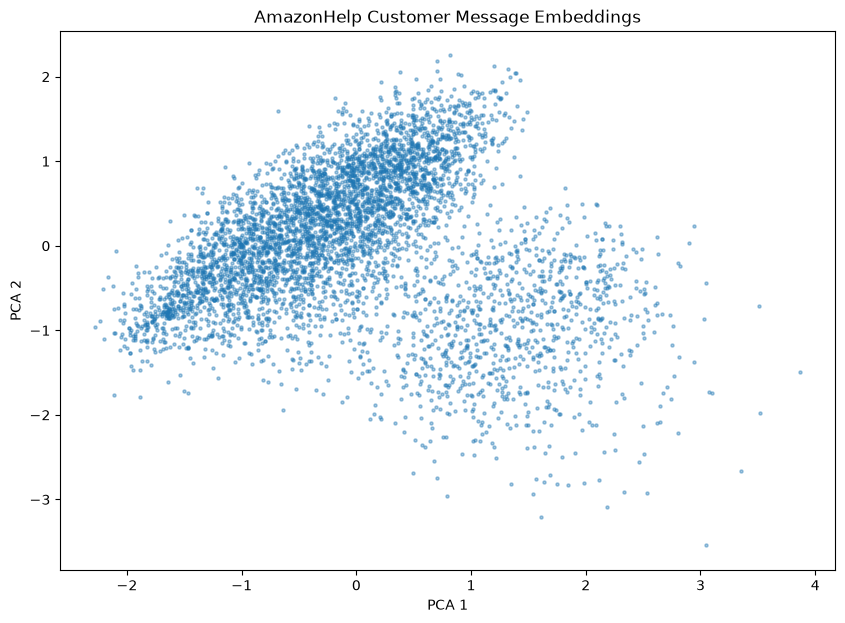

In [47]:
plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    s=5,
    alpha=0.4
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("AmazonHelp Customer Message Embeddings")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(embeddings)

intent_sample["cluster"] = cluster_labels

print(intent_sample["cluster"].value_counts().sort_index())

cluster
0    402
1    277
2    625
3    401
4    293
5    536
6    777
7    362
8    545
9    782
Name: count, dtype: int64


In [52]:
for cluster_id in sorted(intent_sample["cluster"].unique()):

    cluster_data = intent_sample[
        intent_sample["cluster"] == cluster_id
    ]

    print("\n" + "=" * 100)
    print(
        f"CLUSTER {cluster_id} "
        f"({len(cluster_data)} messages)"
    )

    samples = cluster_data.sample(
        min(10, len(cluster_data)),
        random_state=42
    )

    for text in samples["customer_text_clean"]:
        print("-", text)


CLUSTER 0 (402 messages)
- I guess they are not to help, but they want to get help, ask all questions but don't have single answers #AmazonCheater
- is there a way if you could tell me if I qualify for a trial for amazon prime? I remember signing up for it before prime video was launched in Canada I think? I’m just not sure I wanna make that $100 dive for the 12 months.
- amazon.it
- They are unable to find my order...ftw.😔😣 I tried around 100 times to call but still no response. Let me speak to representative direct or solve my bad experience with amazon here.
- I am having trouble with my account. Amazon keeps deactivating my password and that I will be able to access my account and change my password in 5 hours. I changed my password and it is not letting me into my account. I have reset my password and it says not valid.
- Amazon is 3rd class company never go for it Go for flipkart indian company !!
- The sale was awesome.. #DiwaliKiTayari #AmazonGreatIndianSale
- Amazon unable to

In [53]:
cluster_sizes = (
    intent_sample["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="messages")
)

cluster_sizes

,cluster,messages
0,0,402
1,1,277
2,2,625
3,3,401
4,4,293
5,5,536
6,6,777
7,7,362
8,8,545
9,9,782


### Multilingual Model(For tweets which servers meaning in multiple languages)

In [48]:
model_multi = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1965.66it/s]


In [58]:
embeddings_en = model_en.encode(
    intent_sample["customer_text_clean"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

embeddings_multi = model_multi.encode(
    intent_sample["customer_text_clean"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print("English:", embeddings_en.shape)
print("Multilingual:", embeddings_multi.shape)

Batches: 100%|██████████| 79/79 [00:49<00:00,  1.60it/s]

English: (5000, 384)
Multilingual: (5000, 384)


In [59]:
kmeans_multi = KMeans(
    n_clusters=10,
    random_state=42,
    n_init=10
)

cluster_labels_multi = kmeans_multi.fit_predict(embeddings_multi)

intent_sample["cluster_multi"] = cluster_labels_multi

In [60]:
def inspect_cluster(cluster_id, n=15):
    cluster_data = intent_sample[
        intent_sample["cluster_multi"] == cluster_id
    ]

    print("=" * 100)
    print(f"CLUSTER {cluster_id}")
    print(f"Number of messages: {len(cluster_data)}")
    print("=" * 100)

    samples = cluster_data.sample(
        min(n, len(cluster_data)),
        random_state=42
    )

    for i, text in enumerate(samples["customer_text_clean"], 1):
        print(f"{i}. {text}")

In [61]:
for i in range(10):
    inspect_cluster(i)

CLUSTER 0
Number of messages: 378
1. I don't know, it never shipped. Then I contacted your customer service and it updated to shipping Monday for delivery Tuesday.
2. So mad, ordered this router on prime now uk,not only has it been opened,it hasn't even got a power supply.I needed it today!
3. my parcel has gone missing and now nobody is replying to my emails! Horrendous
4. what is the point in having delivery instructions if your drivers ignores them?
5. Why do send tiny items in massive boxes 📦
6. Ordered from and I get a delivery of an empty box. #Frustrated
7. No, just saying address was invalid. It is a new build but it’s definitely correct. Any chance delivery can be re-attempted as it’s a gift?
8. okay but can I get my shipping money back if I paid for one-day shipping but they keep delaying its delivery
9. yes its supposed to be delivered on the earliest next delivery tomorrow but still i find it insane that a driver can do this.
10. Which was missing 3 items. Called cs and was

In [ ]:
k_values = [8, 10, 12, 15]

silhouette_results = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(embeddings_multi)

    score = silhouette_score(
        embeddings_multi,
        labels
    )

    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_results

[{'k': 8, 'silhouette_score': 0.046997230499982834},
 {'k': 10, 'silhouette_score': 0.046136729419231415},
 {'k': 12, 'silhouette_score': 0.034435492008924484},
 {'k': 15, 'silhouette_score': 0.03435032069683075}]

In [63]:
pd.DataFrame(silhouette_results)

,k,silhouette_score
0,8,0.046997
1,10,0.046137
2,12,0.034435
3,15,0.034350


# Candidate Intent Taxonomy

The initial intent taxonomy was derived using a combination of:
- TF-IDF keyword analysis
- multilingual sentence embeddings
- K-Means clustering
- manual inspection of customer → AmazonHelp support pairs
- iterative split/merge decisions based on operational boundaries

The taxonomy is intentionally based on **customer intent**, rather than simply the topic or product mentioned in the message.

> **Important:** This is a candidate taxonomy and will be validated further using frequency, coherence, boundary clarity, historical resolution consistency, and golden-set annotation.

---

## 1. Delivery

| Intent | Definition | Boundary / Examples |
|---|---|---|
| `DELIVERY_DELAY` | Customer's expected or promised delivery is late | "My order was supposed to arrive yesterday." Prime-related delivery delays also belong here. |
| `DELIVERY_NOT_RECEIVED` | Customer has not received the expected package/order | Entire shipment is missing. Different from `MISSING_ITEM`, where the package arrived but an item is missing. |
| `DELIVERY_TRACKING` | Customer needs information about shipment tracking or the shipment status is unclear/stuck | "Where is my package?", "Tracking hasn't updated." |
| `DELIVERY_DRIVER_ISSUE` | Problem specifically involving the delivery driver, carrier, delivery attempt, or delivery instructions | Driver misconduct, failed delivery attempts, driver not following instructions, etc. |

---

## 2. Orders

| Intent | Definition | Boundary / Examples |
|---|---|---|
| `ORDER_STATUS` | Customer wants to know the current state of an order | General order status such as whether it has shipped or is being processed. Do not use when the primary issue is carrier tracking. |
| `ORDER_CANCELLATION` | Customer wants to cancel an order or an order was unexpectedly cancelled | Includes cancellation requests and unexpected order cancellations. |
| `MISSING_ITEM` | Customer received an order/package but one or more expected items are missing | "I ordered 4 items but only received 3." Different from `DELIVERY_NOT_RECEIVED`, where the entire shipment is missing. |
| `WRONG_ITEM_RECEIVED` | Customer received an incorrect or duplicate product instead of the expected item | "I ordered headphones but received a phone case." |

---

## 3. Post-Purchase

| Intent | Definition | Boundary / Examples |
|---|---|---|
| `RETURN_REPLACEMENT` | Customer wants to return a product or obtain a replacement | Includes return requests, replacement requests, and cases where damaged/defective products are explicitly being returned/replaced. |
| `REFUND_PAYMENT` | Customer is waiting for, requesting, or investigating a refund after a return/cancellation/etc. | "I returned the item two weeks ago, where is my refund?" |

---

## 4. Account

| Intent | Definition | Boundary / Examples |
|---|---|---|
| `ACCOUNT_ACCESS` | Customer cannot access or manage their account | Login problems, locked/suspended accounts, forgotten passwords, verification preventing access. |
| `ACCOUNT_SECURITY` | Customer suspects unauthorized access, hacking, fraud, or other account-security compromise | Hacked account, fraudulent activity, suspicious account changes/transactions. |

---

## 5. Payments / Financial

| Intent | Definition | Boundary / Examples |
|---|---|---|
| `UNEXPECTED_CHARGE` | Customer does not recognize, understand, or expected a different charge | Unexpected charge, duplicate charge, unexplained charge, unexpected Prime charge. |
| `CASHBACK` | Customer has not received an expected cashback/reward amount | Promotional cashback or reward not credited. |

---

## 6. Product

| Intent | Definition | Boundary / Examples |
|---|---|---|
| `PRODUCT_ISSUE` | Product is damaged, defective, broken, faulty, poor quality, incompatible, or not functioning as expected | "My Fire Stick isn't working", "The product arrived damaged", "The product is defective." If the customer's explicit primary request is to return/replace it, use `RETURN_REPLACEMENT`. |

---

# Contextual Attributes

Some frequently occurring topics should **not automatically become intents**.

### Prime

`Prime` is currently treated as a **contextual attribute**, not an intent.

Examples:

```text
"Prime delivery is two days late"
→ DELIVERY_DELAY
Context: Prime

"I can't log into my Prime account"
→ ACCOUNT_ACCESS
Context: Prime

"Why was I charged for Prime?"
→ UNEXPECTED_CHARGE
Context: Prime

# Taxonomy Validation

Each candidate intent will be evaluated on five dimensions:

1. **Frequency** — Is the intent common enough to justify its own class?
2. **Coherence** — Do messages assigned to the intent represent the same customer problem?
3. **Boundary clarity** — Can annotators reliably distinguish it from similar intents?
4. **Resolution consistency** — Do similar cases receive similar historical support actions?
5. **Operational value** — Does separating the intent improve response generation or escalation decisions?

An intent should be retained only when the distinction is useful and sufficiently observable in the historical data.

In [80]:
text = amazon_pairs["customer_text_clean"].str.lower()

intent_proxies = {
    "DELIVERY_DELAY": [
        "delayed", "delay", "late", "late delivery",
        "delivery date", "supposed to arrive"
    ],

    "DELIVERY_NOT_RECEIVED": [
        "not received", "haven't received", "didn't receive",
        "never received", "not arrived", "hasn't arrived"
    ],

    "DELIVERY_TRACKING": [
        "tracking", "tracking number", "tracking id",
        "tracking says", "track my"
    ],

    "DELIVERY_DRIVER_ISSUE": [
        "delivery driver", "driver", "courier",
        "delivery person", "attempted delivery"
    ],

    "ORDER_STATUS": [
        "order status", "status of my order",
        "where is my order", "order update"
    ],

    "ORDER_CANCELLATION": [
        "cancel my order", "cancel order",
        "order cancelled", "order canceled"
    ],

    "MISSING_ITEM": [
        "missing item", "item missing",
        "missing from my order", "missing items"
    ],

    "WRONG_ITEM_RECEIVED": [
        "wrong item", "incorrect item",
        "received the wrong", "wrong product"
    ],

    "RETURN_REPLACEMENT": [
        "return", "replacement", "replace",
        "send replacement"
    ],

    "REFUND_PAYMENT": [
        "refund", "refunded", "money back"
    ],

    "ACCOUNT_ACCESS": [
        "can't login", "cannot login", "can't log in",
        "cannot log in", "locked account",
        "account blocked", "password"
    ],

    "ACCOUNT_SECURITY": [
        "hacked", "fraud", "fraudulent",
        "unauthorized", "someone accessed",
        "security"
    ],

    "UNEXPECTED_CHARGE": [
        "charged", "charge", "charged twice",
        "unexpected charge", "why was i charged"
    ],

    "CASHBACK": [
        "cashback", "cash back"
    ],

    "PRODUCT_ISSUE": [
        "damaged", "broken", "defective",
        "faulty", "not working", "poor quality"
    ]
}

In [81]:
proxy_counts = {}

for intent, keywords in intent_proxies.items():
    pattern = "|".join(re.escape(k) for k in keywords)
    mask = text.str.contains(pattern, regex=True, na=False)
    proxy_counts[intent] = mask.sum()

proxy_counts_df = (
    pd.DataFrame.from_dict(
        proxy_counts,
        orient="index",
        columns=["proxy_count"]
    )
    .sort_values("proxy_count", ascending=False)
)

proxy_counts_df

,proxy_count
DELIVERY_DELAY,7815
REFUND_PAYMENT,6518
RETURN_REPLACEMENT,6316
DELIVERY_DRIVER_ISSUE,4217
PRODUCT_ISSUE,2921
UNEXPECTED_CHARGE,2553
DELIVERY_NOT_RECEIVED,2474
DELIVERY_TRACKING,2217
ACCOUNT_SECURITY,1640
CASHBACK,1068


In [82]:
overlap_df = pd.DataFrame(index=amazon_pairs.index)

for intent, keywords in intent_proxies.items():
    pattern = "|".join(re.escape(k) for k in keywords)
    overlap_df[intent] = text.str.contains(
        pattern,
        regex=True,
        na=False
    )

overlap_df["num_matches"] = overlap_df.sum(axis=1)

overlap_df["num_matches"].value_counts().sort_index()

num_matches
0    133732
1     27634
2      4960
3       577
4        56
5         4
Name: count, dtype: int64

In [83]:
overlap_df[overlap_df["num_matches"] >= 3].head(30)

,DELIVERY_DELAY,DELIVERY_NOT_RECEIVED,DELIVERY_TRACKING,DELIVERY_DRIVER_ISSUE,ORDER_STATUS,ORDER_CANCELLATION,MISSING_ITEM,WRONG_ITEM_RECEIVED,RETURN_REPLACEMENT,REFUND_PAYMENT,ACCOUNT_ACCESS,ACCOUNT_SECURITY,UNEXPECTED_CHARGE,CASHBACK,PRODUCT_ISSUE,num_matches
295,True,True,True,False,False,False,False,False,False,False,False,False,False,False,False,3
558,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,3
646,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,3
685,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,3
764,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,3
1659,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,3
2165,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,3
2382,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,3
2385,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,3
2524,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,3


# Candidate Intent Taxonomy

## Delivery

1. `DELIVERY_DELAY`
2. `DELIVERY_NOT_RECEIVED`
3. `DELIVERY_TRACKING`
4. `DELIVERY_DRIVER_ISSUE`

## Orders

5. `ORDER_STATUS`
6. `ORDER_CANCELLATION`
7. `MISSING_ITEM`
8. `WRONG_ITEM_RECEIVED`

## Post-Purchase

9. `RETURN_REPLACEMENT`
10. `REFUND_STATUS`

## Account

11. `ACCOUNT_ACCESS`
12. `ACCOUNT_SECURITY`

## Financial

13. `UNEXPECTED_CHARGE`
14. `CASHBACK`

## Product

15. `PRODUCT_ISSUE`

# Taxonomy Validation Matrix

| Intent | Frequency | Coherence | Boundary Clarity | Resolution Consistency | Operational Value | Decision |
|---|---|---|---|---|---|---|
| DELIVERY_DELAY | TBD | TBD | TBD | TBD | TBD | TBD |
| DELIVERY_NOT_RECEIVED | TBD | TBD | TBD | TBD | TBD | TBD |
| DELIVERY_TRACKING | TBD | TBD | TBD | TBD | TBD | TBD |
| DELIVERY_DRIVER_ISSUE | TBD | TBD | TBD | TBD | TBD | TBD |
| ORDER_STATUS | TBD | TBD | TBD | TBD | TBD | TBD |
| ORDER_CANCELLATION | TBD | TBD | TBD | TBD | TBD | TBD |
| MISSING_ITEM | TBD | TBD | TBD | TBD | TBD | TBD |
| WRONG_ITEM_RECEIVED | TBD | TBD | TBD | TBD | TBD | TBD |
| RETURN_REPLACEMENT | TBD | TBD | TBD | TBD | TBD | TBD |
| REFUND_STATUS | TBD | TBD | TBD | TBD | TBD | TBD |
| ACCOUNT_ACCESS | TBD | TBD | TBD | TBD | TBD | TBD |
| ACCOUNT_SECURITY | TBD | TBD | TBD | TBD | TBD | TBD |
| UNEXPECTED_CHARGE | TBD | TBD | TBD | TBD | TBD | TBD |
| CASHBACK | TBD | TBD | TBD | TBD | TBD | TBD |
| PRODUCT_ISSUE | TBD | TBD | TBD | TBD | TBD | TBD |

In [84]:
# Distance of every message to its assigned cluster centroid
distances = kmeans.transform(embeddings_multi)

intent_sample["cluster_distance"] = [
    distances[i, cluster]
    for i, cluster in enumerate(intent_sample["cluster"])
]

intent_sample[
    ["customer_text_clean", "cluster", "cluster_distance"]
].sort_values("cluster_distance").head(20)

,customer_text_clean,cluster,cluster_distance
95067,Gracias,3,0.845417
27111,Obrigado.,3,0.989817
109495,わざわざありがとうございます！ 参照させていただきます😊,3,1.004153
37614,"Chegaram! Obrigada, 📚",3,1.009564
127383,Muchas gracias.,3,1.043807
17301,わざわざありがとうございます！ カスタマーにて問い合わせ中です！,3,1.225106
112756,ひぐらしのなく頃に解をどうか配信お願いします😭,7,1.274746
155259,架空請求きたよww しかもショートメールでAmazon相談係。,2,1.276154
78659,Ab- uns wieder anmelden hat geholfen. Danke! 😊,3,1.320694
52430,Porqué tarda tanto en tomar un pedido 😨,7,1.339069


In [85]:
from sklearn.metrics.pairwise import cosine_similarity

embedding_lookup = {
    idx: embeddings_multi[i]
    for i, idx in enumerate(intent_sample.index)
}

In [86]:
intent_prototypes = {
    "DELIVERY_DELAY": "my package delivery is late or delayed",
    "DELIVERY_NOT_RECEIVED": "my package was not received or is missing",
    "DELIVERY_TRACKING": "where is my package tracking status",
    "DELIVERY_DRIVER_ISSUE": "problem with delivery driver or delivery attempt",

    "ORDER_STATUS": "what is the status of my order",
    "ORDER_CANCELLATION": "I want to cancel my order",
    "MISSING_ITEM": "an item is missing from my delivered order",
    "WRONG_ITEM_RECEIVED": "I received the wrong item",

    "RETURN_REPLACEMENT": "I want to return or replace a product",
    "REFUND_STATUS": "where is my refund",

    "ACCOUNT_ACCESS": "I cannot access or log into my account",
    "ACCOUNT_SECURITY": "my account has been hacked or compromised",

    "UNEXPECTED_CHARGE": "I was charged unexpectedly or charged twice",
    "CASHBACK": "I have not received my cashback",

    "PRODUCT_ISSUE": "my product is broken defective damaged or not working"
}

In [87]:
prototype_embeddings = model_multi.encode(
    list(intent_prototypes.values()),
    normalize_embeddings=True
)

In [ ]:
intent_candidates = {}

sample_embeddings = np.array(embeddings_multi)

for i, intent in enumerate(intent_prototypes):

    similarities = cosine_similarity(
        prototype_embeddings[i].reshape(1, -1),
        sample_embeddings
    )[0]

    top_indices = similarities.argsort()[-30:][::-1]

    result = intent_sample.iloc[top_indices].copy()
    result["similarity"] = similarities[top_indices]

    intent_candidates[intent] = result

: 